# TSCV 多折交叉验证评估

扫描 `model/TSCV/` 目录，汇总所有已完成的 TSCV 实验结果，筛选最优模型。

评分指标: `cv_score = mean_sharpe - std_sharpe`

In [24]:
1

1

In [25]:
import os, sys, json, glob
import pandas as pd
import numpy as np

sys.path.insert(0, '../code/src')
import warnings
warnings.filterwarnings('ignore')

TSCV_DIR = "../model/TSCV"

## 1. 加载 TSCV 结果

In [26]:
rows = []
for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
    model_type = os.path.basename(os.path.normpath(mt_dir))
    parts = model_type.split("_")
    mt_short = parts[1] if len(parts) >= 2 else model_type

    for exp_dir in sorted(glob.glob(f"{mt_dir}exp_*/")):
        result_file = os.path.join(exp_dir, "tscv_results.json")
        config_file = os.path.join(exp_dir, "config.json")
        if not os.path.exists(result_file):
            continue
        with open(result_file) as f:
            r = json.load(f)
        if not r.get("success"):
            continue

        exp_idx = int(os.path.basename(os.path.normpath(exp_dir)).split("_")[1])
        folds_done = sum(1 for d in sorted(glob.glob(f"{exp_dir}fold_*/"))
                        if os.path.exists(os.path.join(d, "epoch_scores.txt")))
        folds_total = len(r.get("fold_sharpe", []))
        params = r.get("params", {})

        row = {
            "model_type": mt_short,
            "exp_idx": exp_idx,
            "cv_score": r.get("cv_score", r.get("sharpe", 0)),
            "mean_sharpe": r.get("mean_sharpe", 0),
            "std_sharpe": r.get("std_sharpe", 0),
            "mean_calmar": r.get("mean_calmar", 0),
            "mean_max_dd": r.get("mean_max_dd", 0),
            "mean_sortino": r.get("mean_sortino", 0),
            "mean_win_rate": r.get("mean_win_rate", 0),
            "folds_done": folds_done,
            "folds_total": folds_total,
            "lr": params.get("learning_rate", 0),
            "d_model": params.get("d_model", 0),
            "dropout": params.get("dropout", 0),
            "num_layers": params.get("num_layers", 0),
            "kernel_size": params.get("kernel_size", 0),
        }
        rows.append(row)

df = pd.DataFrame(rows) if rows else pd.DataFrame()
print(f"共加载 {len(df)} 个实验")
display(df["model_type"].value_counts())
if len(df) > 0:
    display(df[['model_type', 'exp_idx', 'cv_score', 'mean_sharpe', 'std_sharpe',
                'mean_max_dd', 'mean_sortino', 'mean_win_rate',
                'folds_done', 'folds_total']].sort_values(by=['cv_score'], ascending=[False]).head())

共加载 61 个实验


model_type
tcn        21
dlinear    20
gru        20
Name: count, dtype: int64

,model_type,exp_idx,cv_score,mean_sharpe,std_sharpe,mean_max_dd,mean_sortino,mean_win_rate,folds_done,folds_total
8,dlinear,17,2.378302,2.412075,0.033773,8.811650,3.867275,0.541350,4,4
52,tcn,22,2.323376,2.419500,0.096124,10.307775,3.964000,0.685550,4,4
56,tcn,5,2.186520,2.375500,0.188980,6.898525,3.981225,0.759000,4,4
27,gru,16,2.175156,2.936525,0.761369,7.032175,4.767350,0.758800,4,4
25,gru,14,2.074148,2.482125,0.407977,9.213700,4.069300,0.716925,4,4


## 2. 实验综合排名


### 2.1 按 CV Score 排名

按 `cv_score = mean_sharpe - std_sharpe` 排序。


,model_type,exp_idx,cv_score,mean_sharpe,std_sharpe,mean_calmar,mean_max_dd,mean_sortino,mean_win_rate,folds_done,folds_total,lr,d_model,dropout,num_layers,kernel_size,rank
0,dlinear,17,2.378302,2.412075,0.033773,8.936900,8.811650,3.867275,0.541350,4,4,0.000415,128,0.183346,1,25,1
1,tcn,22,2.323376,2.419500,0.096124,7.720150,10.307775,3.964000,0.685550,4,4,0.000119,64,0.196560,3,3,2
2,tcn,5,2.186520,2.375500,0.188980,8.232575,6.898525,3.981225,0.759000,4,4,0.000064,128,0.178518,3,3,3
3,gru,16,2.175156,2.936525,0.761369,10.029800,7.032175,4.767350,0.758800,4,4,0.000210,64,0.174564,2,0,4
4,gru,14,2.074148,2.482125,0.407977,7.727025,9.213700,4.069300,0.716925,4,4,0.000291,64,0.159723,2,0,5
5,tcn,19,1.928548,2.252050,0.323502,7.751475,11.750125,3.520050,0.710775,4,4,0.000116,64,0.174827,3,3,6
6,tcn,7,1.897028,2.499275,0.602247,7.765775,7.603000,3.781575,0.609275,4,4,0.000213,64,0.144015,4,3,7
7,gru,10,1.890084,2.448525,0.558441,8.876075,8.192300,3.970675,0.812450,4,4,0.000288,64,0.160321,2,0,8
8,tcn,17,1.768858,2.516775,0.747917,7.593675,6.762400,3.530775,0.779100,4,4,0.000185,128,0.179483,4,3,9
9,tcn,15,1.726102,2.502850,0.776748,8.564825,9.369150,3.771250,0.738400,4,4,0.000090,64,0.154854,4,3,10


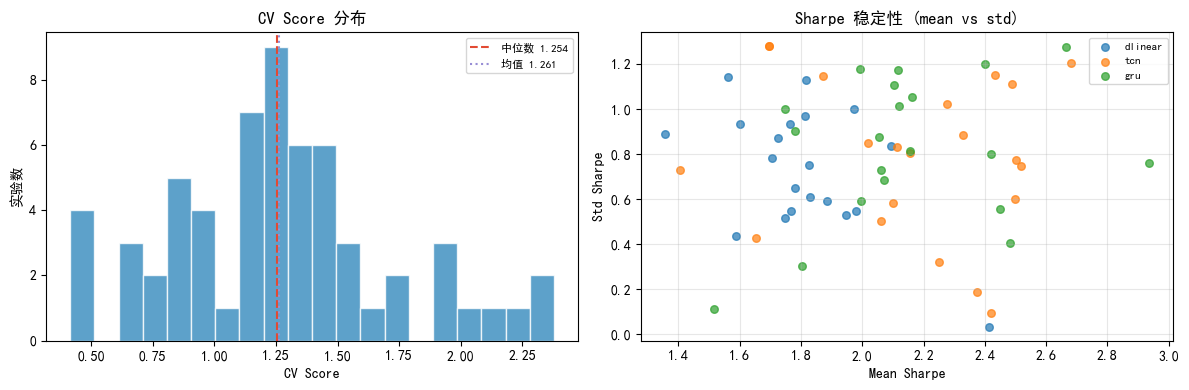

In [27]:
if len(df) > 0:
    ranked = df.sort_values('cv_score', ascending=False).reset_index(drop=True)
    ranked['rank'] = range(1, len(ranked) + 1)
    cols = ['rank', 'model_type', 'exp_idx', 'cv_score',
            'mean_sharpe', 'std_sharpe', 'mean_max_dd', 'mean_sortino', 'mean_win_rate']

    # 分位数着色排名表
    def _highlight(val, col_name, table):
        higher_better = ('cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate')
        lower_better = ('std_sharpe', 'mean_max_dd')
        if col_name in higher_better:
            if val >= table[col_name].quantile(0.8):
                return 'background-color: #006837; color: white'
            elif val >= table[col_name].quantile(0.6):
                return 'background-color: #2aa054; color: white'
            elif val >= table[col_name].quantile(0.4):
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        elif col_name in lower_better:
            if val <= table[col_name].quantile(0.2):
                return 'background-color: #006837; color: white'
            elif val <= table[col_name].quantile(0.4):
                return 'background-color: #2aa054; color: white'
            elif val <= table[col_name].quantile(0.6):
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        return ''
    styled = ranked.style.map(lambda v: _highlight(v, 'cv_score', ranked), subset=['cv_score'])
    styled = styled.map(lambda v: _highlight(v, 'std_sharpe', ranked), subset=['std_sharpe'])
    styled = styled.map(lambda v: _highlight(v, 'mean_max_dd', ranked), subset=['mean_max_dd'])
    styled = styled.map(lambda v: _highlight(v, 'mean_sharpe', ranked), subset=['mean_sharpe'])
    styled = styled.map(lambda v: _highlight(v, 'mean_sortino', ranked), subset=['mean_sortino'])
    styled = styled.map(lambda v: _highlight(v, 'mean_win_rate', ranked), subset=['mean_win_rate'])
    display(styled)

    # CV Score 分布直方图
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.hist(ranked['cv_score'], bins=20, color='#348ABD', edgecolor='white', alpha=0.8)
    ax.axvline(ranked['cv_score'].median(), color='#E24A33', linestyle='--', label=f"中位数 {ranked['cv_score'].median():.3f}")
    ax.axvline(ranked['cv_score'].mean(), color='#988ED5', linestyle=':', label=f"均值 {ranked['cv_score'].mean():.3f}")
    ax.set_xlabel('CV Score')
    ax.set_ylabel('实验数')
    ax.set_title('CV Score 分布')
    ax.legend(fontsize=8)

    ax = axes[1]
    for mt in ranked['model_type'].unique():
        sub = ranked[ranked['model_type'] == mt]
        ax.scatter(sub['mean_sharpe'], sub['std_sharpe'], label=mt, s=30, alpha=0.7)
    ax.set_xlabel('Mean Sharpe')
    ax.set_ylabel('Std Sharpe')
    ax.set_title('Sharpe 稳定性 (mean vs std)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
else:
    print("暂无完成的 TSCV 结果")

### 2.2 按综合评分排名

对每个指标计算分位数评分（0-1），加权求和得到综合评分。
越高越好的指标: cv_score, mean_sharpe, mean_sortino, mean_win_rate
越低越好的指标: std_sharpe, mean_max_dd


,rank,model_type,exp_idx,composite_score,q_cv_score,q_mean_sharpe,q_mean_sortino,q_mean_win_rate,q_std_sharpe,q_mean_max_dd,cv_score,mean_sharpe,mean_sortino,mean_win_rate,std_sharpe,mean_max_dd
0,1,tcn,5,0.896175,0.967213,0.770492,0.918033,0.819672,0.934426,0.967213,2.186520,2.375500,3.981225,0.759000,0.188980,6.898525
1,2,gru,16,0.874317,0.950820,1.000000,0.983607,0.803279,0.557377,0.950820,2.175156,2.936525,4.767350,0.758800,0.761369,7.032175
2,3,gru,10,0.871585,0.885246,0.868852,0.901639,0.983607,0.754098,0.836066,1.890084,2.448525,3.970675,0.812450,0.558441,8.192300
3,4,tcn,17,0.833333,0.868852,0.950820,0.721311,0.885246,0.590164,0.983607,1.768858,2.516775,3.530775,0.779100,0.747917,6.762400
4,5,gru,14,0.833333,0.934426,0.885246,0.950820,0.622951,0.885246,0.721311,2.074148,2.482125,4.069300,0.716925,0.407977,9.213700
5,6,tcn,22,0.792350,0.983607,0.819672,0.885246,0.508197,0.967213,0.590164,2.323376,2.419500,3.964000,0.685550,0.096124,10.307775
6,7,tcn,7,0.770492,0.901639,0.918033,0.852459,0.344262,0.688525,0.918033,1.897028,2.499275,3.781575,0.609275,0.602247,7.603000
7,8,dlinear,17,0.767760,1.000000,0.803279,0.868852,0.196721,0.983607,0.754098,2.378302,2.412075,3.867275,0.541350,0.033773,8.811650
8,9,tcn,15,0.759563,0.852459,0.934426,0.836066,0.721311,0.540984,0.672131,1.726102,2.502850,3.771250,0.738400,0.776748,9.369150
9,10,tcn,19,0.691257,0.918033,0.721311,0.704918,0.540984,0.901639,0.360656,1.928548,2.252050,3.520050,0.710775,0.323502,11.750125


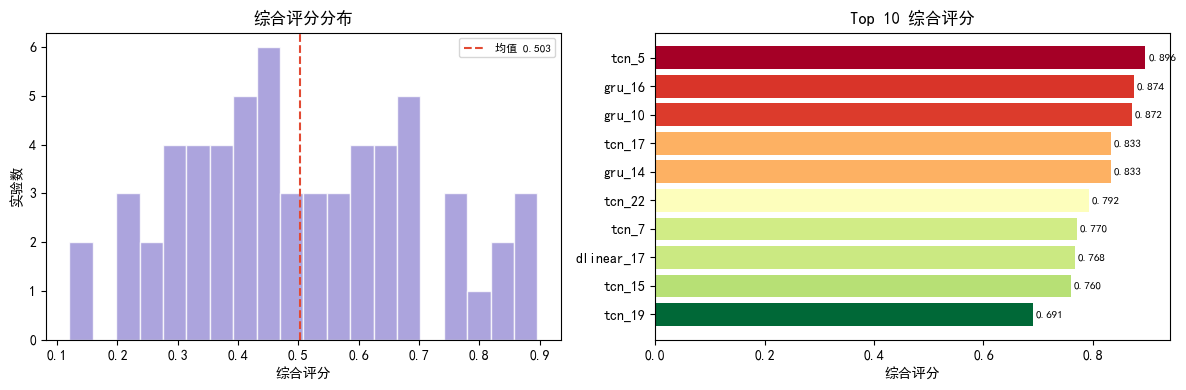

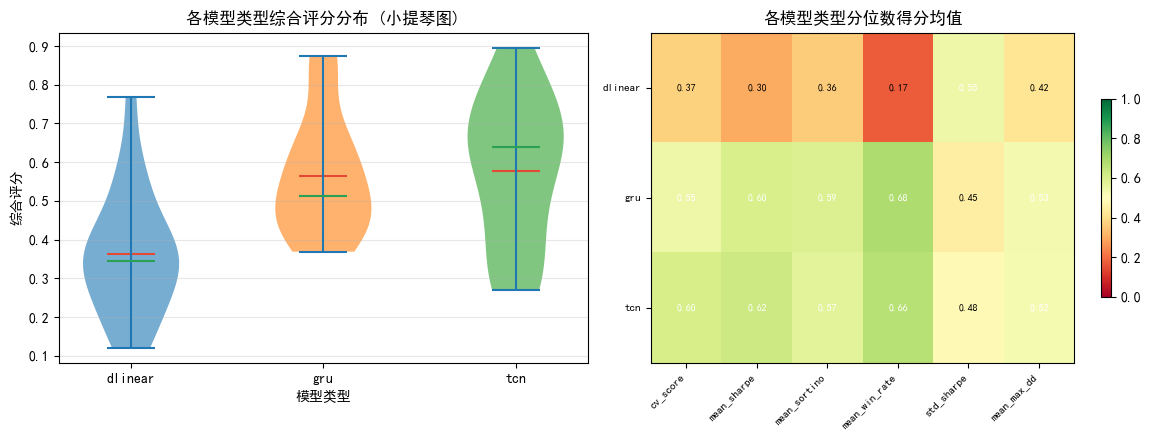

In [30]:
if len(df) > 0:
    # 分位数综合评分
    higher_better = ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']
    lower_better = ['std_sharpe', 'mean_max_dd']

    composite = df[['model_type', 'exp_idx'] + higher_better + lower_better].copy()
    for col in higher_better:
        composite[f'q_{col}'] = composite[col].rank(pct=True)
    for col in lower_better:
        composite[f'q_{col}'] = 1 - composite[col].rank(pct=True)

    q_cols = [f'q_{c}' for c in higher_better + lower_better]
    composite['composite_score'] = composite[q_cols].mean(axis=1)
    composite = composite.sort_values('composite_score', ascending=False).reset_index(drop=True)
    composite['rank'] = range(1, len(composite) + 1)

    display_cols = ['rank', 'model_type', 'exp_idx', 'composite_score'] + [f'q_{c}' for c in higher_better + lower_better] + higher_better + lower_better

    # 分位数着色
    def _highlight_all(val, col_name, table):
        if col_name.startswith('q_'):
            if val >= 0.8:
                return 'background-color: #006837; color: white'
            elif val >= 0.6:
                return 'background-color: #2aa054; color: white'
            elif val >= 0.4:
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        return ''
    styled = composite[display_cols].style.map(
        lambda v: _highlight_all(v, 'composite_score', composite), 
        subset=['composite_score']
    )
    for col in q_cols:
        if col in display_cols:
            styled = styled.map(lambda v, c=col: _highlight_all(v, c, composite), subset=[col])

    display(styled)

    # 综合评分分布
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax = axes[0]
    ax.hist(composite['composite_score'], bins=20, color='#988ED5', edgecolor='white', alpha=0.8)
    ax.axvline(composite['composite_score'].mean(), color='#E24A33', linestyle='--', label=f"均值 {composite['composite_score'].mean():.3f}")
    ax.set_xlabel('综合评分')
    ax.set_ylabel('实验数')
    ax.set_title('综合评分分布')
    ax.legend(fontsize=8)

    ax = axes[1]
    top10 = composite.head(10)
    colors = plt.cm.RdYlGn(1 - (top10['composite_score'] - top10['composite_score'].min()) / (top10['composite_score'].max() - top10['composite_score'].min() + 1e-8))
    ax.barh(range(len(top10)), top10['composite_score'], color=colors)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([f"{r['model_type']}_{r['exp_idx']}" for _, r in top10.iterrows()])
    ax.set_xlabel('综合评分')
    ax.set_title('Top 10 综合评分')
    ax.invert_yaxis()
    for i, v in enumerate(top10['composite_score']):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    # 各模型类别综合评分分布
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ax = axes[0]
    mt_labels = sorted(composite['model_type'].unique())
    mt_groups = [composite[composite['model_type'] == mt]['composite_score'] for mt in mt_labels]

    vp = ax.violinplot(mt_groups, positions=range(len(mt_labels)), showmeans=True, showmedians=True)
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(plt.cm.tab10(i % 10))
        body.set_alpha(0.6)
    vp['cmeans'].set_color('#E24A33')
    vp['cmedians'].set_color('#2aa054')
    ax.set_xticks(range(len(mt_labels)))
    ax.set_xticklabels(mt_labels)
    ax.set_xlabel('模型类型')
    ax.set_ylabel('综合评分')
    ax.set_title('各模型类型综合评分分布 (小提琴图)')
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1]
    mt_avg = composite.groupby('model_type')[q_cols].mean()
    im = ax.imshow(mt_avg.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(q_cols)))
    ax.set_xticklabels([c.replace('q_', '') for c in q_cols], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(mt_avg)))
    ax.set_yticklabels(mt_avg.index, fontsize=8)
    ax.set_title('各模型类型分位数得分均值')
    for i in range(len(mt_avg)):
        for j in range(len(q_cols)):
            v = mt_avg.values[i, j]
            color = 'white' if v > 0.5 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)
    plt.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("暂无完成的 TSCV 结果")

## 3. 模型优选


模型选择结果

DLINEAR:
  Best: exp_17  cv_score=2.3783
  mean_sharpe=2.4121  std_sharpe=0.0338
  mean_max_dd=8.81%  mean_sortino=3.87  mean_win_rate=54.13%
  score=0.77
  超参: lr=4.15e-04  d_model=128  dropout=0.183
        kernel_size=25  num_layers=1
  同类型分布: cv_score 中位数=1.1010  Q1=0.8389  Q3=1.2374  IQR=0.3984
  💡 提示: cv_score=2.3783 > 温和离群上界=1.8350 (Q3+1.5*IQR)，结果较好但需关注可复现性

GRU:
  Best: exp_16  cv_score=2.1752
  mean_sharpe=2.9365  std_sharpe=0.7614
  mean_max_dd=7.03%  mean_sortino=4.77  mean_win_rate=75.88%
  score=0.87
  超参: lr=2.10e-04  d_model=64  dropout=0.175
        num_layers=2
  同类型分布: cv_score 中位数=1.3352  Q1=1.0759  Q3=1.4281  IQR=0.3521
  💡 提示: cv_score=2.1752 > 温和离群上界=1.9562 (Q3+1.5*IQR)，结果较好但需关注可复现性

TCN:
  Best: exp_5  cv_score=2.1865
  mean_sharpe=2.3755  std_sharpe=0.1890
  mean_max_dd=6.90%  mean_sortino=3.98  mean_win_rate=75.90%
  score=0.90
  超参: lr=6.42e-05  d_model=128  dropout=0.179
        kernel_size=3  num_layers=3
  同类型分布: cv_score 中位数=1.3763  Q1=1.2248  Q3=1

,ranking,model_type,exp_idx,cv_score,mean_sharpe,mean_max_dd,mean_sortino,mean_win_rate,score
56,1,tcn,5,2.186520,2.375500,6.898525,3.981225,0.75900,0.896175
27,2,gru,16,2.175156,2.936525,7.032175,4.767350,0.75880,0.874317
8,3,dlinear,17,2.378302,2.412075,8.811650,3.867275,0.54135,0.767760


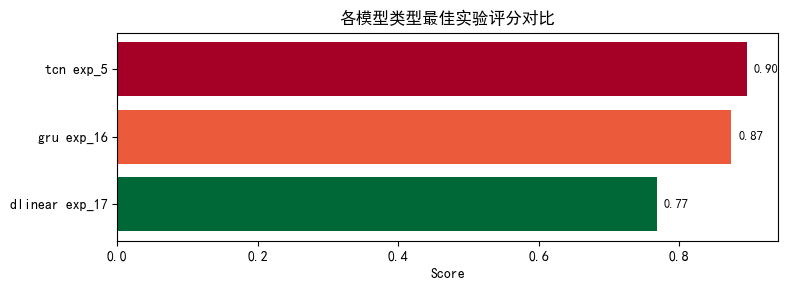

In [ ]:
if len(df) > 0 and 'mean_max_dd' in df.columns:
    score_df = df.copy()
    higher_better = ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']
    lower_better = ['std_sharpe', 'mean_max_dd']
    for col in higher_better:
        score_df[f'q_{col}'] = score_df[col].rank(pct=True)
    for col in lower_better:
        score_df[f'q_{col}'] = 1 - score_df[col].rank(pct=True)
    q_cols = [f'q_{c}' for c in higher_better + lower_better]
    score_df['score'] = score_df[q_cols].mean(axis=1)

    print("=" * 70)
    print("模型选择结果")
    print("=" * 70)

    best_per_type = []
    for mt in score_df['model_type'].unique():
        sub = score_df[score_df['model_type'] == mt]
        threshold = sub['cv_score'].quantile(0.85)
        top_group = sub[sub['cv_score'] >= threshold].copy()
        if len(top_group) == 0:
            top_group = sub.nlargest(max(1, len(sub) // 5), 'cv_score')
        top_group = top_group.sort_values('score', ascending=False)
        best = top_group.iloc[0]
        best_per_type.append(best)

        # 离群检验: 检查该实验在同类型中是否严重偏离
        q1, q3 = sub['cv_score'].quantile(0.25), sub['cv_score'].quantile(0.75)
        iqr = q3 - q1
        outlier_upper = q3 + 3.0 * iqr
        outlier_lower = q1 - 3.0 * iqr
        is_outlier = best['cv_score'] > outlier_upper

        print(f"\n{mt.upper()}:")
        print(f"  Best: exp_{int(best['exp_idx'])}  cv_score={best['cv_score']:.4f}")
        print(f"  mean_sharpe={best['mean_sharpe']:.4f}  std_sharpe={best['std_sharpe']:.4f}")
        print(f"  mean_max_dd={best['mean_max_dd']:.2f}%  mean_sortino={best['mean_sortino']:.2f}  mean_win_rate={best['mean_win_rate']:.2%}")
        print(f"  score={best['score']:.2f}")
        print(f"  超参: lr={best['lr']:.2e}  d_model={int(best['d_model'])}  dropout={best['dropout']:.3f}")
        if 'kernel_size' in best and best['kernel_size'] > 0:
            print(f"        kernel_size={int(best['kernel_size'])}  num_layers={int(best['num_layers'])}")
        else:
            print(f"        num_layers={int(best['num_layers'])}")

        # 同类型分布统计
        print(f"  同类型分布: cv_score 中位数={sub['cv_score'].median():.4f}  "
              f"Q1={q1:.4f}  Q3={q3:.4f}  IQR={iqr:.4f}")
        if is_outlier:
            print(f"  ⚠️  警告: cv_score={best['cv_score']:.4f} > 离群上界={outlier_upper:.4f} (Q3+3*IQR)，"
                  f"该实验可能为严重离群值，建议谨慎选用")
        elif best['cv_score'] > q3 + 1.5 * iqr:
            print(f"  💡 提示: cv_score={best['cv_score']:.4f} > 温和离群上界={q3 + 1.5 * iqr:.4f} (Q3+1.5*IQR)，"
                  f"结果较好但需关注可复现性")

    print("\n" + "=" * 70)
    print("全推荐排名表")
    print("=" * 70)
    best_df = pd.DataFrame(best_per_type).sort_values('score', ascending=False)
    best_df['ranking'] = range(1, len(best_df) + 1)
    display(best_df[['ranking', 'model_type', 'exp_idx', 'cv_score',
                     'mean_sharpe', 'mean_max_dd', 'mean_sortino', 'mean_win_rate', 'score']])

    # 最佳模型评分对比
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(8, max(3, len(best_df) * 0.4)))
    colors = plt.cm.RdYlGn(1 - (best_df['score'] - best_df['score'].min()) /
                           (best_df['score'].max() - best_df['score'].min() + 1e-8))
    ax.barh(range(len(best_df)), best_df['score'], color=colors)
    ax.set_yticks(range(len(best_df)))
    ax.set_yticklabels([f"{r['model_type']} exp_{int(r['exp_idx'])}" for _, r in best_df.iterrows()])
    ax.set_xlabel('Score')
    ax.set_title('各模型类型最佳实验评分对比')
    ax.invert_yaxis()
    for i, v in enumerate(best_df['score']):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("数据不足以进行模型选择（缺少 mean_max_dd）")


## 4. 部署

选择排名第一的模型，生成部署配置。


最佳模型: tcn_exp_5
  目录: ../model/TSCV\bayes_tcn_74_3\exp_5
  cv_score: 2.1865  mean_sharpe: 2.3755  mean_max_dd: 6.90%
  full/ 模型: ❌
  单折模型: 4/4 折可用

方案一: 全量重训 (推荐)
  训练全量模型:
    python code/src/model_manager.py retrain --source TSCV\bayes_tcn_74_3\exp_5
  完成后添加至 config.yaml:
  config.yaml 配置:
    - dir: TSCV\bayes_tcn_74_3\exp_5/full
      file: best_model_sharpe.pth
      enabled: true

方案二: 单折模型
  fold_3 可用 (含 config.json + best_model_sharpe.pth)
  config.yaml 配置:
    - dir: TSCV\bayes_tcn_74_3\exp_5/fold_3
      file: best_model_sharpe.pth
      enabled: true

方案三: 集成 Folds (ensemble_folds)
  使用全部 4 个可用折的模型进行集成推理
  config.yaml 配置:
    - dir: TSCV\bayes_tcn_74_3\exp_5
      type: ensemble_folds
      file: best_model_sharpe.pth
      enabled: true
  ⚠️  需要 config.json 在 TSCV\bayes_tcn_74_3\exp_5 目录中
  ✅ config.json 存在


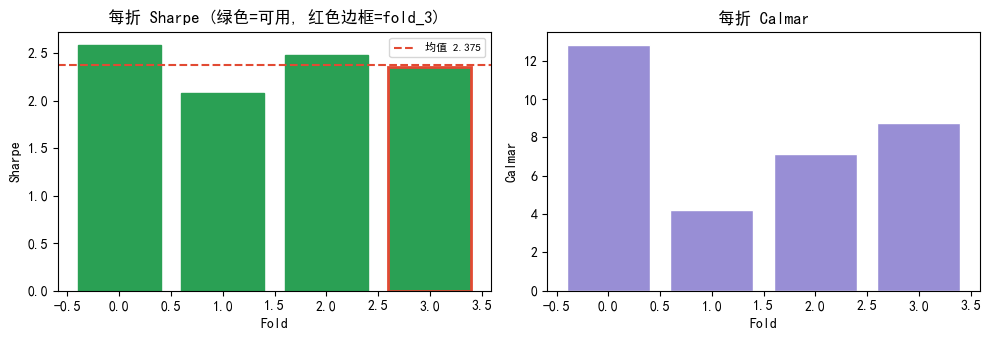


验证命令
  python code/src/daily_eval.py --predictions-only --no-update
  python code/src/daily_eval.py --from-predictions --no-update


In [ ]:
if len(df) > 0 and 'mean_max_dd' in df.columns:
    score_df = df.copy()
    higher_better = ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']
    lower_better = ['std_sharpe', 'mean_max_dd']
    for col in higher_better:
        score_df[f'q_{col}'] = score_df[col].rank(pct=True)
    for col in lower_better:
        score_df[f'q_{col}'] = 1 - score_df[col].rank(pct=True)
    q_cols = [f'q_{c}' for c in higher_better + lower_better]
    score_df['score'] = score_df[q_cols].mean(axis=1)

    best_overall = score_df.sort_values('score', ascending=False).iloc[0]
    mt = best_overall['model_type']
    exp_idx = int(best_overall['exp_idx'])

    best_dir = None
    for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
        model_type = os.path.basename(os.path.normpath(mt_dir))
        parts = model_type.split("_")
        mt_short = parts[1] if len(parts) >= 2 else model_type
        if mt_short == mt:
            exp_dir = os.path.join(mt_dir, f"exp_{exp_idx}")
            if os.path.exists(exp_dir):
                best_dir = exp_dir
                break

    if best_dir:
        rel_dir = os.path.relpath(best_dir, start=os.path.join(TSCV_DIR, ".."))
        full_dir = os.path.join(best_dir, "full")
        has_full = os.path.exists(full_dir)
        fold_dirs = sorted(glob.glob(os.path.join(best_dir, "fold_*/")))
        has_folds = len(fold_dirs) > 0
        # Check if fold dirs have config.json and best_model_sharpe.pth
        valid_folds = [d for d in fold_dirs if
                       os.path.exists(os.path.join(d, "best_model_sharpe.pth"))]
        has_valid_folds = len(valid_folds) > 0

        print("=" * 70)
        print(f"最佳模型: {mt}_exp_{exp_idx}")
        print(f"  目录: {best_dir}")
        print(f"  cv_score: {best_overall['cv_score']:.4f}  mean_sharpe: {best_overall['mean_sharpe']:.4f}  mean_max_dd: {best_overall['mean_max_dd']:.2f}%")
        print(f"  full/ 模型: {'✅' if has_full else '❌'}")
        print(f"  单折模型: {f'{len(valid_folds)}/{len(fold_dirs)} 折可用' if has_folds else '无'}")
        print()

        # ----- 方案一: 重训 (full) -----
        print("=" * 70)
        print("方案一: 全量重训 (推荐)")
        print("=" * 70)
        if not has_full:
            print(f"  训练全量模型:")
            print(f"    python code/src/model_manager.py retrain --source {rel_dir}")
            print(f"  完成后添加至 config.yaml:")
        print(f"  config.yaml 配置:")
        print(f"""    - dir: {rel_dir}/full
      file: best_model_sharpe.pth
      enabled: true""")

        # ----- 方案二: 单折 (fold_3) -----
        print()
        print("=" * 70)
        print("方案二: 单折模型")
        print("=" * 70)
        target_fold = "fold_3"
        fold_path = os.path.join(best_dir, target_fold)
        if os.path.exists(fold_path):
            if os.path.exists(os.path.join(fold_path, "best_model_sharpe.pth")):
                print(f"  {target_fold} 可用 (含 config.json + best_model_sharpe.pth)")
                print(f"  config.yaml 配置:")
                print(f"""    - dir: {rel_dir}/{target_fold}
      file: best_model_sharpe.pth
      enabled: true""")
            else:
                print(f"  ⚠️  {target_fold} 目录存在但缺少 config.json 或 best_model_sharpe.pth，不可直接使用")
                if has_valid_folds:
                    print(f"  可选的其他折: {[os.path.basename(d.rstrip('/')) for d in valid_folds]}")
        else:
            print(f"  ⚠️  {target_fold} 不存在")
            if has_valid_folds:
                alt = os.path.basename(valid_folds[0].rstrip("/"))
                print(f"  可选: 使用 {alt} 代替")
                print(f"  config.yaml 配置:")
                print(f"""    - dir: {rel_dir}/{alt}
      file: best_model_sharpe.pth
      enabled: true""")
            else:
                print(f"  ❌ 无可用单折模型")

        # ----- 方案三: 集成fold -----
        print()
        print("=" * 70)
        print("方案三: 集成 Folds (ensemble_folds)")
        print("=" * 70)
        if has_valid_folds:
            print(f"  使用全部 {len(valid_folds)} 个可用折的模型进行集成推理")
            print(f"  config.yaml 配置:")
            print(f"""    - dir: {rel_dir}
      type: ensemble_folds
      file: best_model_sharpe.pth
      enabled: true""")
            print(f"  ⚠️  需要 config.json 在 {rel_dir} 目录中")
            has_parent_cfg = os.path.exists(os.path.join(best_dir, "config.json"))
            print(f"  {'✅' if has_parent_cfg else '❌'} config.json {'存在' if has_parent_cfg else '不存在'}")
        else:
            print(f"  ❌ 无可用 fold 模型，无法集成")

        # 最佳模型每折表现
        result_file = os.path.join(best_dir, "tscv_results.json")
        if os.path.exists(result_file):
            with open(result_file) as f:
                br = json.load(f)
            fold_sharpe = br.get("fold_sharpe", [])
            fold_calmar = br.get("fold_calmar", [])
            if fold_sharpe:
                import matplotlib.pyplot as plt
                plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
                plt.rcParams['axes.unicode_minus'] = False
                fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
                ax = axes[0]

                bars = ax.bar(range(len(fold_sharpe)), fold_sharpe, color='#348ABD', edgecolor='white')
                # highlight valid folds
                for i in range(len(fold_sharpe)):
                    fd = os.path.join(best_dir, f"fold_{i}")
                    if os.path.exists(fd) and os.path.exists(os.path.join(fd, "best_model_sharpe.pth")):
                        bars[i].set_color('#2aa054')
                    # mark fold_3 specifically
                    if i == 3 and os.path.exists(os.path.join(best_dir, "fold_3", "best_model_sharpe.pth")):
                        bars[i].set_edgecolor('#E24A33')
                        bars[i].set_linewidth(2)
                ax.axhline(y=br.get('mean_sharpe', 0), color='#E24A33', linestyle='--', label=f"均值 {br.get('mean_sharpe', 0):.3f}")
                ax.set_xlabel('Fold')
                ax.set_ylabel('Sharpe')
                ax.set_title('每折 Sharpe (绿色=可用, 红色边框=fold_3)')
                ax.legend(fontsize=8)
                if fold_calmar:
                    ax = axes[1]
                    ax.bar(range(len(fold_calmar)), fold_calmar, color='#988ED5', edgecolor='white')
                    ax.set_xlabel('Fold')
                    ax.set_ylabel('Calmar')
                    ax.set_title('每折 Calmar')
                plt.tight_layout()
                plt.show()
        print()
        print("=" * 70)
        print("验证命令")
        print("=" * 70)
        print("  python code/src/daily_eval.py --predictions-only --no-update")
        print("  python code/src/daily_eval.py --from-predictions --no-update")
    else:
        print(f"错误: 未找到 {mt}_exp_{exp_idx} 的目录")
else:
    print("暂无 TSCV 结果可供部署")
